# Project data exploration - looking at relplot and scatter plots
Using a dataset that your group is consider using for the term project, let's do some data exploring of the different features in your dataset and their relationships

Group name: team 1 
Created by Alex Hovakimyan(016319888), Gloria Duo(018038020), Julie Nguyen(015783807), Thang Cao(017740411)  
Last updated:   
Briefly describe your dataset

Import your data. If you want to mount your Google drive you can use `from google.colab import drive` and `drive.mount('/content/drive')`

### Load Data

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

data_path = Path('data') / 'baseline_dataset.parquet'

df = pd.read_parquet(data_path)
pd.set_option('display.max_columns', None)

### Q1: Show the number of missing data in each column of the dataframe

In [4]:
# Your code here . . .
missing_values = df.isnull().sum().sort_values(ascending=False)
print(missing_values)

min_val_temperature        67583
last_val_temperature       67583
mean_val_temperature       67583
max_val_temperature        67583
mean_val_bilirubin         40917
                           ...  
ICU_mortality                  0
ICU_endtime                    0
ICU_time_to_event_hours        0
window_24h_end                 0
subject_id                     0
Length: 66, dtype: int64


### Q2: Show the data type for each column of the dataframe

In [10]:
# Your code here . . .
print(df.dtypes)

subject_id                     int32
hadm_id                        int32
stay_id                        int32
first_careunit                object
intime                datetime64[us]
                           ...      
last_val_lactate             float64
last_val_platelets           float64
last_val_potassium           float64
last_val_sodium              float64
last_val_wbc                 float64
Length: 66, dtype: object


### Q3: Create a pair plot to show pairwise relationship in this dataset.
Draw the pairwise polynomial regression lines in a different color than the data points. Use a light color for the data points to deemphasizing the points to make the regression line stand out. Include a meaningful title to the plot.

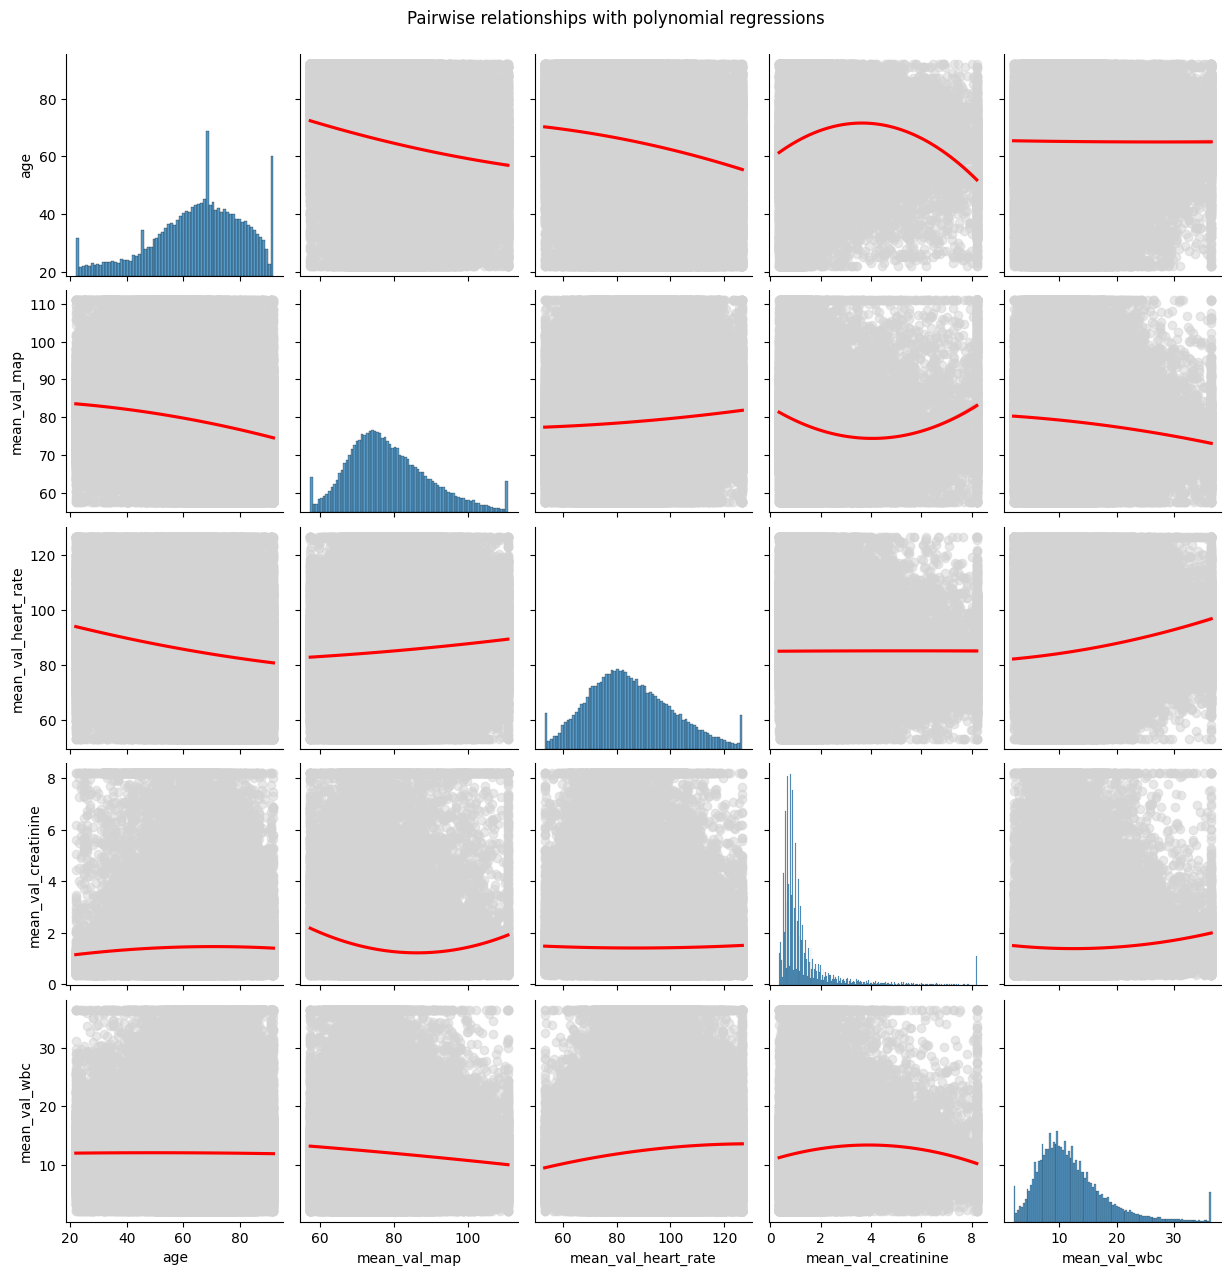

In [4]:
# we pick specific columns because it will
# otherwise take too long to plot 64 x 64 columns
interesting_cols = [
    'age', 
    'mean_val_map', 
    'mean_val_heart_rate', 
    'mean_val_creatinine', 
    'mean_val_wbc'
]

plot_df = df[interesting_cols].dropna()

# to zoom out the points
plot_df = plot_df.clip(             
   lower=plot_df.quantile(0.01),   
   upper=plot_df.quantile(0.99),   
   axis=1                          
)     
graph = sns.pairplot(data=plot_df, kind="reg", 
                     plot_kws={
                        'order': 2,
                        'scatter_kws': {'color': 'lightgray', 'alpha': 0.5},
                        'line_kws': {'color': 'red'}
                     }
)

graph.figure.suptitle("Pairwise relationships with polynomial regressions", y=1.02)
plt.show()

### Interpretation
Most feature relationships are weak or nonlinear, with no strong linear correlations between variables.  
Age shows a slight negative relationship with MAP and heart rate, but the effect is small.  
MAP and heart rate have a mild positive relationship, suggesting some physiological linkage.  
Creatinine and WBC are highly skewed and show nonlinear patterns, indicating potential outliers or severity-driven effects.  
-> Conclusion:
The features show complex, mostly weak and nonlinear relationships, suggesting that simple linear models may be insufficient and that combining multiple features will be important for accurate mortality prediction.

### Q4: Plot a regression line and confidence interval
Select two of the features from your dataset and create a lmplot that shows the linear regression between them. Filter your data as you see fit. Include a meaningful title for the plot.

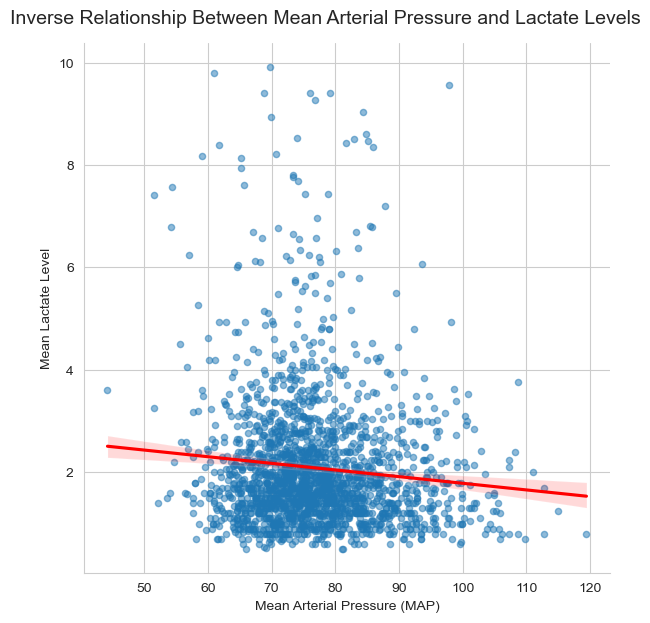

In [10]:
# Your code here . . .

import seaborn as sns
import matplotlib.pyplot as plt

clean_data = df.dropna(subset=["mean_val_creatinine", "ICU_time_to_event_hours"])

clean_data = clean_data[
    (clean_data["mean_val_creatinine"] <= 8) &
    (clean_data["ICU_time_to_event_hours"] <= 150)
]

sample_data = clean_data.sample(1500, random_state=42)

sns.set_style("whitegrid")

plot = sns.lmplot(
    data=sample_data,
    x="mean_val_creatinine",
    y="ICU_time_to_event_hours",
    ci=95,
    height=6,
    aspect=1.5,
    scatter_kws={"alpha": 0.25, "s": 15},
    line_kws={"color": "red", "linewidth": 2}
)

plot.fig.suptitle(
    "Relationship Between Creatinine Levels and ICU Time to Event",
    y=1.02
)

plot.set_axis_labels(
    "Mean Creatinine Level",
    "ICU Time to Event (Hours)"
)

plt.show()

### Interpretation
There is a slight inverse relationship: as mean arterial pressure (MAP) increases, lactate levels tend to decrease.  
However, the relationship is weak, as there is substantial variability and spread in the data.  
This suggests that while lower MAP is associated with higher lactate (poorer perfusion), other factors also strongly influence lactate levels.  
-> Conclusion: MAP and lactate are related in a clinically meaningful way, but MAP alone is not a strong predictor of lactate.

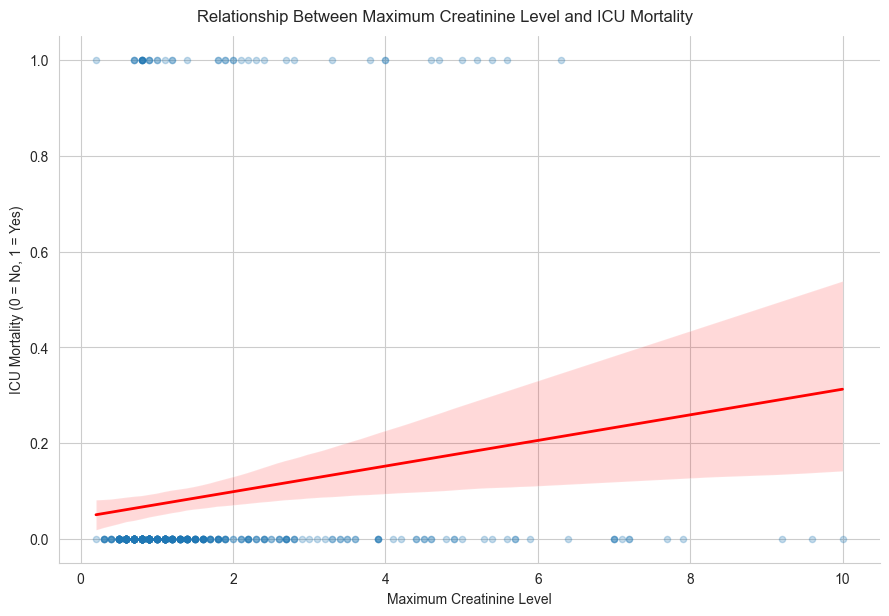

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

clean_data = df.dropna(subset=["max_val_creatinine", "ICU_mortality"])

clean_data = clean_data[clean_data["max_val_creatinine"] <= 10]

sample_data = clean_data.sample(500, random_state=42)

sns.set_style("whitegrid")

plot = sns.lmplot(
    data=sample_data,
    x="max_val_creatinine",
    y="ICU_mortality",
    ci=95,
    height=6,
    aspect=1.5,
    scatter_kws={"alpha": 0.25, "s": 20},
    line_kws={"color": "red", "linewidth": 2}
)


plot.fig.suptitle(
    "Relationship Between Maximum Creatinine Level and ICU Mortality",
    y=1.02
)

plot.set_axis_labels(
    "Maximum Creatinine Level",
    "ICU Mortality (0 = No, 1 = Yes)"
)

plt.show()

### Interpretation
There is a positive relationship: higher maximum creatinine levels are associated with higher ICU mortality.  
Patients who died tend to have higher creatinine values, indicating worse kidney function.  
However, there is still overlap, so creatinine alone is not a perfect predictor.  
-> Conclusion: Elevated creatinine is an important indicator of severity and is associated with increased mortality risk.

### Q5. Create a relplot that shows multiple features in a single plot.
Select two features from your dataset and plot a scatter plot. Select two additional features you want to highlight in your data points using `hue` and `size`. Include a meaningful title to the plot.

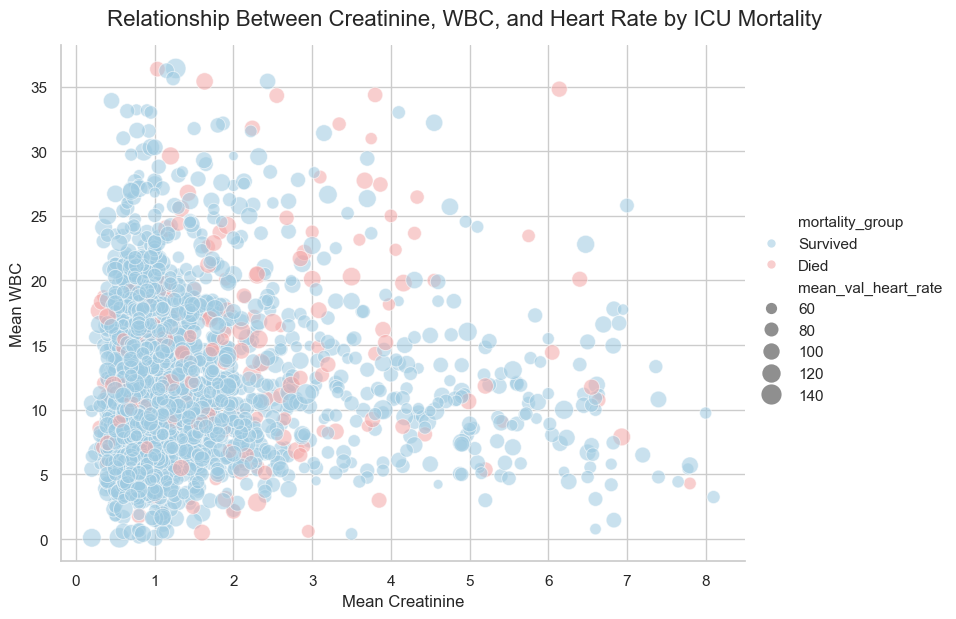

In [7]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_path = Path("data") / "baseline_dataset.parquet"
df = pd.read_parquet(data_path)

plot_df = df[[
    "mean_val_creatinine",
    "mean_val_wbc",
    "mean_val_heart_rate",
    "ICU_mortality"
]].dropna().copy()

plot_df = plot_df[
    (plot_df["mean_val_creatinine"] <= plot_df["mean_val_creatinine"].quantile(0.99)) &
    (plot_df["mean_val_wbc"] <= plot_df["mean_val_wbc"].quantile(0.99)) &
    (plot_df["mean_val_heart_rate"] >= 40) &
    (plot_df["mean_val_heart_rate"] <= 150)
].copy()

plot_df["mortality_group"] = plot_df["ICU_mortality"].astype(int).map({
    0: "Survived",
    1: "Died"
})

plot_df = plot_df.reset_index(drop=True)

if len(plot_df) > 3000:
    plot_df = plot_df.sample(3000, random_state=42).reset_index(drop=True)

sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=plot_df,
    x="mean_val_creatinine",
    y="mean_val_wbc",
    hue="mortality_group",
    size="mean_val_heart_rate",
    kind="scatter",
    sizes=(30, 220),
    alpha=0.55,
    height=6,
    aspect=1.3,
    palette={"Survived": "#9ecae1", "Died": "#f4a6a6"}
)

g.set_axis_labels("Mean Creatinine", "Mean WBC")

g.fig.suptitle(
    "Relationship Between Creatinine, WBC, and Heart Rate by ICU Mortality",
    fontsize=16,
    y=1.03
)

plt.show()

### Interpretation

This plot shows the relationship between creatinine, white blood cell count, and heart rate, with color indicating whether a patient survived or died.

Patients with higher creatinine, higher WBC, and higher heart rate tend to appear more frequently among those who died, suggesting that worse clinical measurements are associated with higher mortality risk.

However, there is still significant overlap between survivors and non-survivors, indicating that no single feature is sufficient to predict mortality. Instead, multiple clinical features need to be considered together.

### Q6: Create a plot with small multiples plots
Select two features from your dataset and show the relationship between the features with an additional feature as the single category. Organize the multiple plots to have 3 plots per row. Set the `height` of the plot to 5 and the size the of data point to 20. Include a meaningful title in the plot.

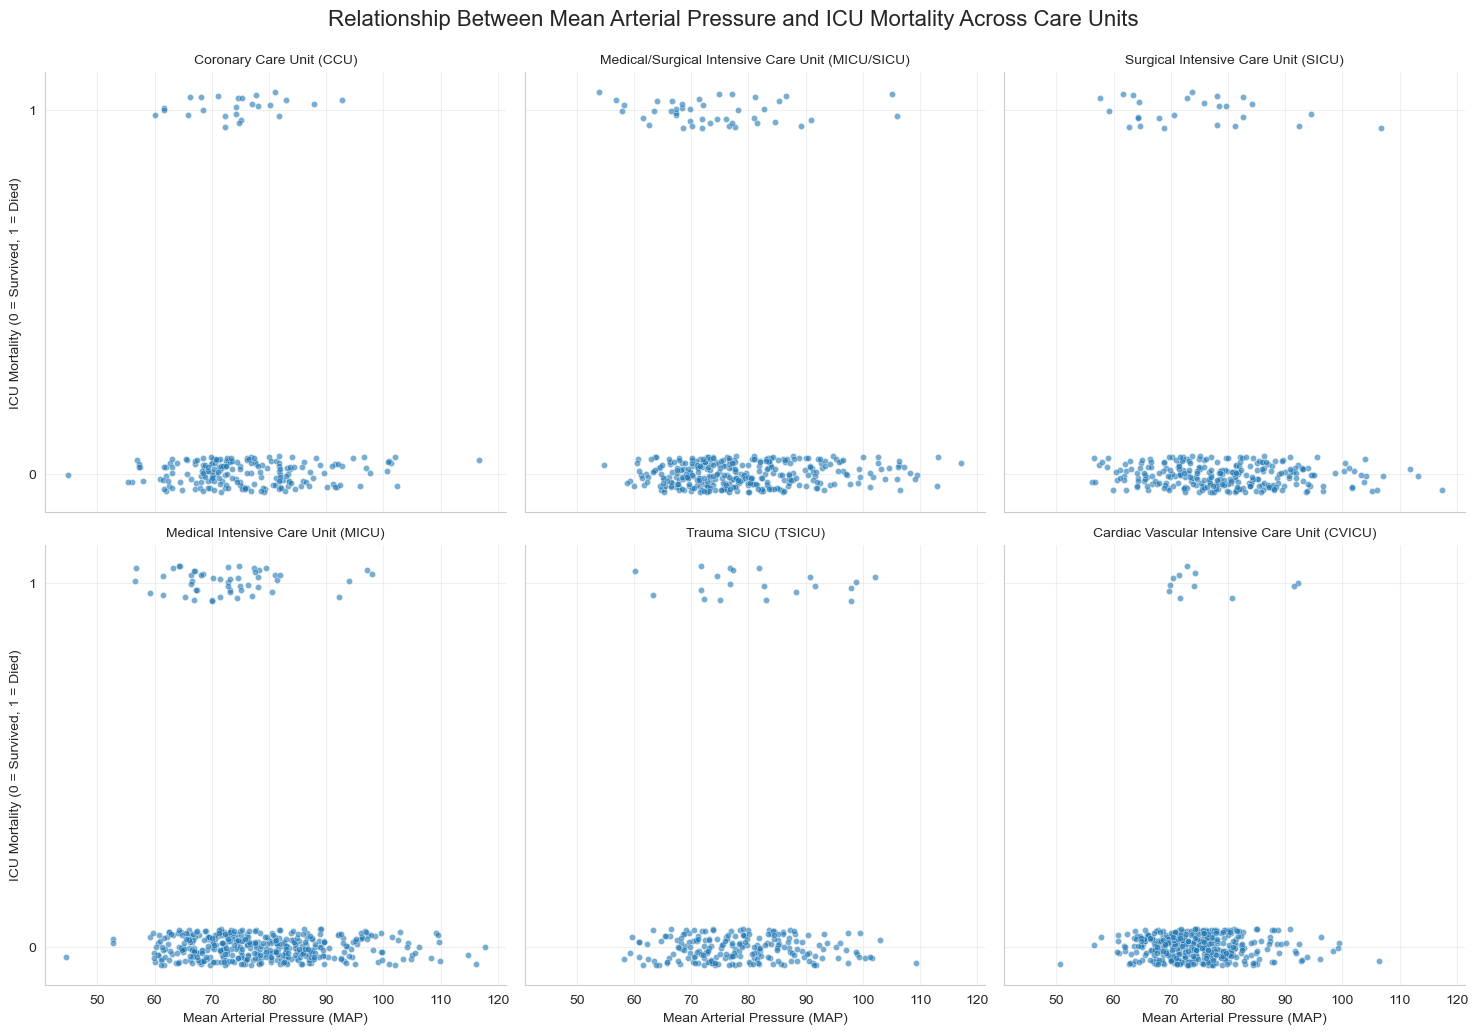

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_style("whitegrid")

plot_df = df.dropna(subset=["mean_val_map", "ICU_mortality", "first_careunit"]).copy()


plot_df["ICU_mortality"] = plot_df["ICU_mortality"].astype(int)


plot_df = plot_df[
    (plot_df["mean_val_map"] >= 40) &
    (plot_df["mean_val_map"] <= 120)
].copy()

# Keep top 6 care units
top_units = plot_df["first_careunit"].value_counts().head(6).index
plot_df = plot_df[plot_df["first_careunit"].isin(top_units)].copy()


if len(plot_df) > 2000:
    plot_df = plot_df.sample(2000, random_state=42)

# Add jitter to mortality for visualization
plot_df["mortality_jitter"] = plot_df["ICU_mortality"] + \
    (np.random.rand(len(plot_df)) - 0.5) * 0.1

# Plot
g = sns.relplot(
    data=plot_df,
    x="mean_val_map",
    y="mortality_jitter",
    col="first_careunit",
    col_wrap=3,     
    kind="scatter",
    height=5,       
    s=20,          
    alpha=0.6
)


g.set_axis_labels("Mean Arterial Pressure (MAP)", "ICU Mortality (0 = Survived, 1 = Died)")
g.set_titles("{col_name}")

g.fig.suptitle(
    "Relationship Between Mean Arterial Pressure and ICU Mortality Across Care Units",
    y=1.03,
    fontsize=16
)

for ax in g.axes.flat:
    ax.set_yticks([0, 1])
    ax.grid(True, alpha=0.3)

plt.show()

### Interpretation
Lower MAP values are associated with higher ICU mortality, indicating worse hemodynamic stability.  
Survivors are more concentrated at moderate-to-higher MAP levels, while deaths appear more at lower ranges.  
This pattern is consistent across care units, suggesting MAP is an important predictor of mortality.